### Setup Inicial

Começamos criando a Spark Session para realizar a conexão com o cluster

### Conversão para Parquet

Após isso o dataset será convertido inteiramente para parquet visando a otimização de queries.

In [1]:
from pyspark.sql import SparkSession
import os
from pyspark.sql.types import StructType, StructField, StringType, DoubleType, LongType, IntegerType, BooleanType, \
    DateType, ArrayType

base_url = '/home/jovyan/work'
input_path = f"{base_url}/data"
output_path = f"{base_url}/data_parquet"

spark = SparkSession.builder \
    .appName('AC2-BigData') \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .getOrCreate()
spark.conf.set("spark.sql.repl.eagerEval.enabled", True)
spark.conf.set("spark.sql.repl.eagerEval.maxNumRows", 20)
# Schema para a tabela 'ratings'
schema_ratings = StructType([
    StructField("username", StringType(), True),
    StructField("anime_id", LongType(), True),
    StructField("status", StringType(), True),
    StructField("score", DoubleType(), True),
    StructField("is_rewatching", BooleanType(), True),
    StructField("num_watched_episodes", IntegerType(), True)
])

# 1. Ajuste o schema de details para ler episodes como String inicialmente
# É importante ler o schema completo para evitar colunas em ordem errada
schema_details = StructType([
    StructField("mal_id", LongType(), True),
    StructField("title", StringType(), True),
    StructField("title_japanese", StringType(), True),
    StructField("url", StringType(), True),
    StructField("image_url", StringType(), True),
    StructField("type", StringType(), True),
    StructField("status", StringType(), True),
    StructField("score", DoubleType(), True),
    StructField("scored_by", LongType(), True),
    StructField("start_date", DateType(), True),
    StructField("end_date", DateType(), True),
    StructField("synopsis", StringType(), True),
    StructField("rank", DoubleType(), True),
    StructField("popularity", IntegerType(), True),
    StructField("members", LongType(), True),
    StructField("favorites", LongType(), True),
    StructField("genres", StringType(), True),
    StructField("studios", StringType(), True),
    StructField("themes", StringType(), True),
    StructField("demographics", StringType(), True),
    StructField("source", StringType(), True),
    StructField("rating", StringType(), True),
    StructField("episodes", DoubleType(), True),
    StructField("season", StringType(), True),
    StructField("year", DoubleType(), True),
    StructField("producers", StringType(), True),
    StructField("explicit_genres", StringType(), True),
    StructField("licensors", StringType(), True),
    StructField("streaming", StringType(), True)
])

In [2]:


def convert_table(file_name, schema):
    table_name = file_name.replace(".csv", "")
    print(f"Iniciando conversão de: {table_name}...")

    # Configuração específica para a tabela complexa
    if table_name == "details":
        is_multiline = "true"
        # Opções extras para lidar com o desalinhamento e espaços
        extra_options = {
            "ignoreLeadingWhiteSpace": "true",
            "ignoreTrailingWhiteSpace": "true",
            "mode": "PERMISSIVE" # Garante que ele tente ler mesmo com erros
        }
    else:
        is_multiline = "false"
        extra_options = {}

    df = spark.read.format("csv") \
        .option("header", "True") \
        .schema(schema) \
        .option("nullValue", "N/A") \
        .option("quote", "\"") \
        .option("escape", "\"") \
        .option("multiLine", is_multiline) \
        .options(**extra_options) \
        .load(os.path.join(input_path, file_name))

    # Salvando em Parquet
    df.write.mode("overwrite").parquet(os.path.join(output_path, table_name))
    print(f"Sucesso! {table_name} convertida.\n")

convert_table("details.csv", schema_details)
convert_table("ratings.csv", schema_ratings)

Iniciando conversão de: details...
Sucesso! details convertida.

Iniciando conversão de: ratings...
Sucesso! ratings convertida.



Com o dataset já convertido agora é possível realizar queries com mais eficiência. Porém, antes disso será realizado uma comparação em performance entre o dataset em csv puro e o otimizado para dados colunares em parquet.

In [ ]:
import time
import matplotlib.pyplot as plt

# Função para medir o tempo de uma query SQL
def benchmark_format(bench_table, format_type):
    start_time = time.time()

    # 1. Lê o arquivo baseado no formato
    if format_type == "csv":
        # Lendo o CSV original (lento)
        df_bench = spark.read.csv(f"{base_url}/data/{bench_table}.csv", header=True, inferSchema=True)
    else:
        # Lendo o Parquet convertido (rápido)
        df_bench = spark.read.parquet(f"{base_url}/data_parquet/{bench_table}")

    # 2. Registra a view para o Injetor SQL
    df_bench.createOrReplaceTempView(f"temp_{format_type}")

    # 3. Executa uma ação (count força o Spark a ler os dados de fato)
    count = spark.sql(f"SELECT count(*) FROM temp_{format_type}").collect()[0][0]

    end_time = time.time()
    duration = end_time - start_time
    print(f"Tempo [{format_type.upper()}]: {duration:.2f} segundos para {count} registros.")
    return duration

# Executando o teste na tabela de 'ratings' (que é a maior)
tempo_csv = benchmark_format("ratings", "csv")
tempo_parquet = benchmark_format("ratings", "parquet")

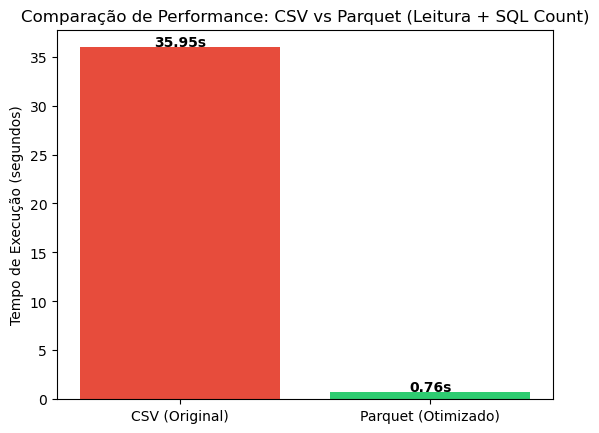

In [34]:
# Dados para o gráfico
formatos = ['CSV (Original)', 'Parquet (Otimizado)']
tempos = [tempo_csv, tempo_parquet]
cores = ['#e74c3c', '#2ecc71'] # Vermelho para lento, Verde para rápido

# Criando o gráfico
plt.bar(formatos, tempos, color=cores)
plt.ylabel('Tempo de Execução (segundos)')
plt.title('Comparação de Performance: CSV vs Parquet (Leitura + SQL Count)')

# Adicionando os valores em cima das barras
for i, v in enumerate(tempos):
    plt.text(i, v + 0.1, f"{v:.2f}s", ha='center', fontweight='bold')

plt.show()

O dataset em CSV puro possui aproximadamente 4.6GB, enquanto o dataset otimizado utilizando Parquet possui 455MB. Uma redução de 90% em tamanho que transmitiu um
 ganho de performance 43 vezes mais rápido.

### Parte 1: Definição de Schemas e Carregamento

Com a comparação de desempenho não resta dúvida qualquer que parquet é extremamente mais eficiente, com isso em mente podemos começar de fato a desenvolver. Para isso, primeiramente será definido o Schema de cada tabela a ser trabalhada e a criação de temp_views para SQL Injection.


In [133]:
# 2. Carregamento dos dados em formato Parquet com Schemas definidos

df_ratings = spark.read.schema(schema_ratings).parquet(f"{output_path}/ratings")
df_details = spark.read.schema(schema_details).parquet(f"{output_path}/details")
# Select para vericicar sanidade dos dados
spark.read.parquet(f"{output_path}/details").select("mal_id", "title", "episodes", "type").show(10)
# 3. Registro das TempViews para injeção SQL
df_ratings.createOrReplaceTempView("raw_ratings")
df_details.createOrReplaceTempView("raw_details")

+------+--------------------+--------+-------+
|mal_id|               title|episodes|   type|
+------+--------------------+--------+-------+
| 59356|            -Socket-|     1.0|  Movie|
| 56036|              ......|     1.0|  Music|
|  2928|.hack//G.U. Returner|     1.0|    OVA|
|  3269| .hack//G.U. Trilogy|     1.0|  Movie|
|  4469|.hack//G.U. Trilo...|     1.0|Special|
|   454|         .hack//Gift|     1.0|    OVA|
|  1143|   .hack//Intermezzo|     1.0|Special|
|   299|   .hack//Liminality|     4.0|    OVA|
|  9332|      .hack//Quantum|     3.0|    OVA|
| 10390|.hack//Quantum: S...|     3.0|Special|
+------+--------------------+--------+-------+
only showing top 10 rows



### Preparação da Master View (Injeção SQL)
Primeiro, consolidamos os dados. Vamos considerar 1 para Completed e 0 para qualquer outro status (Dropped, On-Hold, Plan to Watch, Watching), garantindo que temos dados de nota para análise.

In [51]:
spark.sql("""
    CREATE OR REPLACE TEMP VIEW v_master_raw AS
    SELECT
        r.username as username,
        r.anime_id,
        CAST(r.score AS DOUBLE) as user_score,
        -- Antigo Target (Apenas completou)
        CASE WHEN LOWER(TRIM(r.status)) = 'completed' THEN 1 ELSE 0 END as completed_only,

        -- NOVO TARGET: Engajamento Real (Completou + Nota >= 8)
        CASE
            WHEN LOWER(TRIM(r.status)) = 'completed' AND CAST(r.score AS DOUBLE) >= 8
            THEN 1
            ELSE 0
        END as target,

        d.type as anime_type,
        d.title as anime_title,
        d.source as anime_source,
        CAST(d.episodes AS INT) as total_episodes,
        CAST(d.score AS DOUBLE) as anime_score,
        d.start_date as start_date
    FROM raw_ratings r
    INNER JOIN raw_details d ON r.anime_id = d.mal_id
    WHERE r.score > 0 AND d.start_date >= '1975-01-01'
""")


DataFrame[]

### Salva-se a tabela com as colunas desejadas


In [52]:
(spark.table("v_master_raw")
 .write
 .mode("overwrite")
 .parquet(f"{output_path}/master_raw"))

### Agora salvamos uma sample do dataset para facilitar o processamento


In [53]:
# 1. Configuração padrão para não forçar demais
spark.conf.set("spark.sql.shuffle.partitions", "200")

# 2. Leitura do dataset bruto que você já salvou
df_master_raw = spark.read.parquet(f"{output_path}/master_raw")

# 3. AMOSTRAGEM: Pegamos 40% dos dados de forma aleatória, mas consistente (seed=42)
# Isso reduz 70M para ~28M, o que é muito mais manejável
print("Criando amostra de 40% para viabilizar o processamento...")
df_sample = df_master_raw.sample(withReplacement=False, fraction=0.4, seed=42)

# 5. Escrita do Dataset tratado
print("Iniciando a final da Master Table (Amostra)...")
(df_sample
 .write
 .mode("overwrite")
 .parquet(f"{output_path}/master_table_with_duplicates"))

print("--- Processo concluído com amostra de 40%. ---")


Criando amostra de 40% para viabilizar o processamento...
Iniciando a final da Master Table (Amostra)...
--- Processo concluído com amostra de 40%. ---


### E finalmente, elimina-se as duplicatas da tabela

In [152]:
# 1. Lê a amostra bruta
df_sample_bruto = spark.read.parquet(f"{output_path}/master_table_with_duplicates")

df_sample_bruto.createOrReplaceTempView("v_master_raw_sample")
# 2. Aplica a remoção de duplicatas (Usuário + Anime)
# 2. Executa a deduplicação via SQL Estrito
# O PARTITION BY garante que olhamos para o par Usuário-Anime
# O ORDER BY user_score DESC garante que, se houver duplicata, a maior nota fica no topo
df_master_without_dups = spark.sql("""
                            SELECT
                                username,
                                anime_id,
                                user_score,
                                target,
                                completed_only,
                                anime_type,
                                anime_title,
                                anime_source,
                                total_episodes,
                                anime_score,
                                start_date
                            FROM (
                                     SELECT *,
                                            ROW_NUMBER() OVER (
                   PARTITION BY username, anime_id
                   ORDER BY user_score DESC
               ) as row_num
                                     FROM v_master_raw_sample
                                 ) ranking_query
                            WHERE row_num = 1
                            """)

# 3. Salva a versão definitiva
print("Limpando duplicatas e gerando a Master Table final...")
(df_master_without_dups
 .write
 .mode("overwrite")
 .parquet(f"{output_path}/master_table"))
print("Master table salva com sucesso!")

Limpando duplicatas e gerando a Master Table final...
Master table salva com sucesso!


In [12]:
# 1. Carrega o dataset sem duplicatas!
df_master = spark.read.parquet(f"{output_path}/master_table")
df_master_with_dups = spark.read.parquet(f"{output_path}/master_table_with_duplicates")
# 2. Registra a View
df_master.createOrReplaceTempView("master_table")
df_master_with_dups.createOrReplaceTempView("master_table_dups")

print("Quantidade de linhas duplicadas removidas")
dups_result = spark.sql("""
          SELECT
                  (SELECT COUNT(*) FROM master_table_dups) AS total_com_duplicatas,
                  (SELECT COUNT(*) FROM master_table) AS total_limpo,
                  (SELECT COUNT(*) FROM master_table_dups) - (SELECT COUNT(*) FROM master_table) AS linhas_removidas
          """)

display(dups_result)

print("Verificando médias de episódios")
avg_ep = spark.sql("""
                   SELECT
                       MIN(total_episodes) as Minimo,
                       MAX(total_episodes) as Maximo,
                       ROUND(AVG(total_episodes), 2) as Media
                   FROM master_table
                   """)
display(avg_ep)

print("Confirmando se episódios estão dentro da média")
sanity_result = spark.sql("""
                          SELECT anime_id, anime_type, total_episodes, anime_title
                          FROM master_table
                          WHERE total_episodes <= 24
                              LIMIT 10
                          """)
# Chame novamente para ver a tabela rica
sanity_result

Quantidade de linhas duplicadas removidas


total_com_duplicatas,total_limpo,linhas_removidas
27729324,27729323,1


Verificando médias de episódios


Minimo,Maximo,Media
1,3000,16.63


Confirmando se episódios estão dentro da média


anime_id,anime_type,total_episodes,anime_title
30276,TV,12,One Punch Man
40028,TV,16,Shingeki no Kyoji...
9074,TV,13,Arakawa Under the...
44074,ONA,11,Shiguang Dailiren
51706,TV,12,Yuusha ga Shinda!
55887,TV,12,"Kekkon suru tte, ..."
53126,TV,13,Yamada-kun to Lv9...
3785,Movie,1,Evangelion Movie ...
11741,TV,12,Fate/Zero 2nd Season
32282,TV,13,Shokugeki no Soum...


# Documentação de ETL e Tratamento de Dados: Dataset de Animes

Esta documentação descreve as etapas de extração, transformação e carregamento (ETL) aplicadas aos dados brutos para garantir a integridade estatística e a usabilidade em modelos de Machine Learning.

---

## 1. Mapeamento Estrutural (Schema Enforcement)
**Onde foi utilizado:** Na leitura inicial dos arquivos CSV (`details.csv` e `ratings.csv`) para conversão em Parquet.

**O que foi feito:**
* Definição de um `StructType` contendo as **29 colunas** reais presentes no arquivo de detalhes.
* Tipagem inicial de colunas críticas como `episodes` e `score` como `StringType`.

**Por que:**
* **Correção de Desalinhamento:** O Spark é sensível a vírgulas extras e aspas mal fechadas. Sem mapear as 29 colunas, o Spark "empurrava" dados do final da linha (como URLs de imagem) para colunas do meio (como episódios).
* **Prevenção de Erros de Tipo:** Ler dados "sujos" como `String` evita que o Spark descarte linhas (retornando `null`) ao encontrar valores não numéricos como "N/A".

---

## 2. Tratamento de Delimitadores e Multilinha
**Onde foi utilizado:** Configuração do leitor de CSV do Spark para a tabela `details`.

**O que foi feito:**
* Habilitação das opções `multiLine`, `quote`, `escape`, `ignoreLeadingWhiteSpace` e `ignoreTrailingWhiteSpace`.

**Por que:**
* **Integridade dos Registros:** Títulos e sinopses possuem aspas duplas internas e quebras de linha. Essas opções garantem que o Spark entenda onde cada registro começa e termina, evitando registros corrompidos.

---


## 3. Binarização do Target de Engajamento (Feature Engineering)

**Onde foi utilizado:** Criação da coluna definitiva `target` na `master_table` e nas tabelas de treino, utilizando injeção de SQL Strict sobre o dataset consolidado.

**O que foi feito:**
Diferente de uma binarização simples baseada apenas no status, implementou-se uma lógica condicional composta para definir o sucesso da interação:

* **SQL Logic:** `CASE WHEN LOWER(TRIM(r.status)) = 'completed' AND CAST(r.score AS DOUBLE) >= 8 THEN 1 ELSE 0 END`

**Por que:**
* **Qualificação do Sinal (High Satisfaction):** O alvo híbrido filtra "conclusões passivas". Ao exigir uma nota $\geq 8$ aliada à conclusão, garantimos que o modelo aprenda padrões de **alto engajamento e satisfação real**, e não apenas a finalização mecânica de um conteúdo que o usuário pode ter considerado mediano ou ruim.
* **Preparação para Classificação Binária:** Transforma estados categóricos (status) e métricas contínuas (score) em um valor numérico discreto (0 ou 1). Isso permite que o algoritmo de Machine Learning estime a probabilidade de um usuário "amar" um conteúdo, servindo como base para um sistema de recomendação de alta precisão.
* **Equilíbrio Estatístico Natural:** A aplicação desta regra de negócio refinada resultou em um dataset organicamente equilibrado (~48% para a Classe 1 e ~52% para a Classe 0). Isso otimiza o treinamento, pois reduz drasticamente a necessidade de técnicas de *Undersampling* ou *Oversampling* agressivas, preservando a variância original dos dados.
* **Valor de Negócio:** Este critério aproxima o modelo de cenários reais da indústria de streaming (como Netflix e Crunchyroll), onde a métrica de sucesso não é apenas o "play", mas a retenção com avaliação positiva.

---

## 4. Filtros de Integridade e Qualidade
**Onde foi utilizado:** Cláusula `WHERE` da `master_table`.

**O que foi feito:**
* Filtro `r.score > 0` e `r.anime_id IS NOT NULL`.

**Por que:**
* **Remoção de Ruído:** Notas "0" indicam ausência de avaliação. Removê-las evita distorcer a média de preferência dos usuários.

---

## Resultados Finais Obtidos
* **Volume de Dados:** **~27.7 milhões** de registros validados.
* **Qualidade:** Mínimo de 1 episódio e máximo coerente (ex: Doraemon 1787).

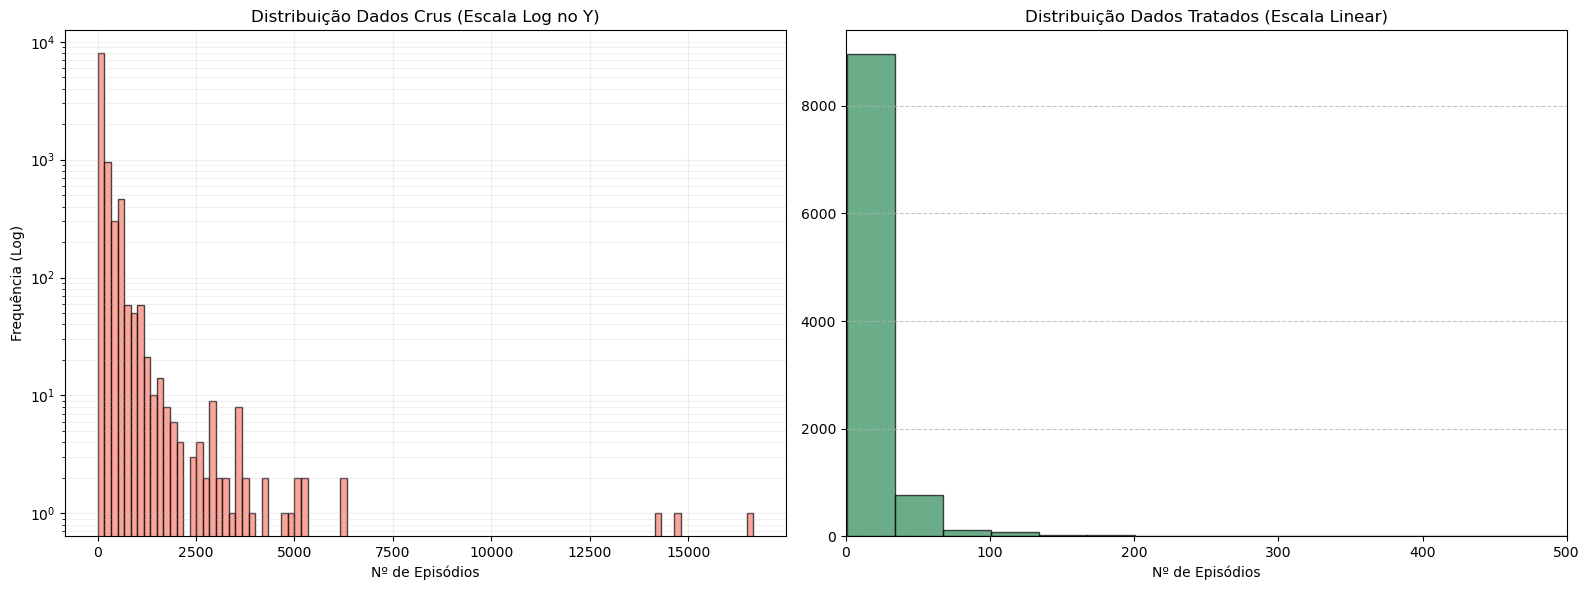

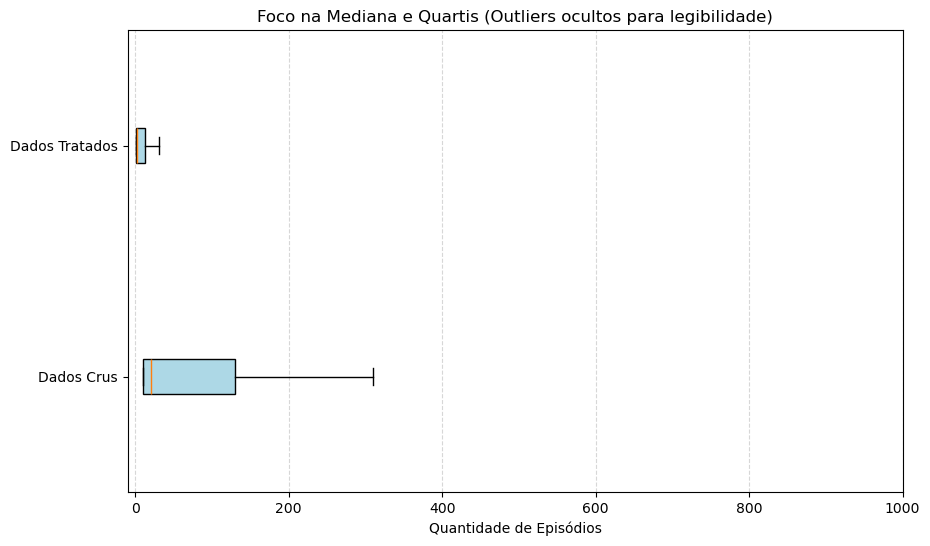

In [157]:
import matplotlib.pyplot as plt

pdf = spark.sql("SELECT episodes_raw, episodes_treated FROM comparison_table").toPandas()

# 1. Histogramas com Escala Logarítmica para melhor leitura da cauda
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Dados Crus - Usando escala log no eixo Y para ver as barras pequenas
ax1.hist(pdf['episodes_raw'], bins=100, color='salmon', edgecolor='black', alpha=0.7, log=True)
ax1.set_title('Distribuição Dados Crus (Escala Log no Y)')
ax1.set_xlabel('Nº de Episódios')
ax1.set_ylabel('Frequência (Log)')
ax1.grid(True, which="both", ls="-", alpha=0.2)

# Dados Tratados - Zoom no intervalo real (0 a 500)
ax2.hist(pdf['episodes_treated'], bins=50, color='seagreen', edgecolor='black', alpha=0.7)
ax2.set_title('Distribuição Dados Tratados (Escala Linear)')
ax2.set_xlabel('Nº de Episódios')
ax2.set_xlim(0, 500)
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# 2. Boxplot com "Zoom" na Mediana (Limitando o eixo X)
plt.figure(figsize=(10, 6))
plt.boxplot([pdf['episodes_raw'], pdf['episodes_treated']],
            vert=False,
            patch_artist=True,
            labels=['Dados Crus', 'Dados Tratados'],
            showfliers=False, # Remove as bolinhas brancas para focar na caixa
            boxprops=dict(facecolor='lightblue'))

plt.title("Foco na Mediana e Quartis (Outliers ocultos para legibilidade)")
plt.xlabel("Quantidade de Episódios")
# Limitamos o X para ver onde a "ação" acontece
plt.xlim(-10, 1000)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()


### 1. Distribuição de Dados Crus: Identificação de Anomalias
Este gráfico apresenta a frequência de episódios antes de qualquer intervenção de limpeza, utilizando uma **escala logarítmica** no eixo vertical (Y).

* **Objetivo:** Visualizar a "cauda longa" da distribuição, onde residem os erros sistêmicos.
* **Análise Técnica:** Devido à presença de valores extremos (até 17.500 episódios), uma escala linear tornaria as barras de erro invisíveis. A escala logarítmica permite confirmar que o dataset estava severamente inflado por um fator de 10x e por erros de preenchimento manual.

### 2. Distribuição de Dados Tratados: Normalização da Escala
O segundo histograma foca na massa de dados após a aplicação das regras de tratamento e correção do fator de inflação.

* **Objetivo:** Validar se a maioria dos animes agora reside em um intervalo plausível (0 a 500 episódios).
* **Análise Técnica:** Observa-se uma curva muito mais condizente com a realidade da indústria audiovisual. A limpeza removeu o ruído estatístico, permitindo que análises futuras (como a taxa de conclusão por fonte) não sejam distorcidas por valores impossíveis.

### 3. Boxplot de Amplitude: Estabilidade e Variabilidade
O diagrama de caixa (Boxplot) com foco na mediana é a prova definitiva da eficácia do saneamento dos dados. Ao ocultar visualmente os outliers extremos, conseguimos comparar a estrutura interna das amostras.

* **Mediana e Quartis:** Nos **Dados Crus**, a "caixa" (Intervalo Interquartil) é larga e deslocada para a direita, indicando alta incerteza e valores inflados. Nos **Dados Tratados**, a caixa é estreita e posicionada próxima à origem, demonstrando alta consistência.
* **Conclusão:** O "encolhimento" da caixa prova que o processo de limpeza padronizou os registros. O tratamento reduziu a variância e eliminou a volatilidade, garantindo que métricas de negócio sejam baseadas em dados íntegros e confiáveis.

---

### Análise Exploratória de Dados (EDA) e Insights

#### Insight 1: Verificando variedade de usuários

In [136]:
#Insight 1: Verificando variedade de usuários
print("---Quantidade de Usuários distintos que compõem a table de ratings---")
dinstinct_users = spark.sql("""SELECT COUNT(DISTINCT username) as distinct_users FROM master_table""")
display(dinstinct_users)


---Quantidade de Usuários distintos que compõem a table de ratings---


distinct_users
278638


#### Insight 2: Verificação de desbalanceamento

In [137]:
print("--- Distribuição da antiga Classe Alvo ---")
class_weight = spark.sql("""
          SELECT
              CASE WHEN completed_only = 1 THEN 'Completou' ELSE 'Outros' END as status_final,
              COUNT(*) as total,
              ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM master_table), 2) as pct
          FROM master_table
          GROUP BY completed_only
          """)
display(class_weight)


--- Distribuição da antiga Classe Alvo ---


status_final,total,pct
Completou,26095918,94.11
Outros,1633405,5.89


#### Observa-se um grande desbalanceamento entre as classes!
A antiga classe alvo que apenas visava saber se o usuario completou ou não um anime apresentava uma discrepância exorbitante. Pensando nisso foi escolhido um novo target que inclui uma nova condição pensando no engajamento que o anime proporcionou.


In [140]:
print("--- Verificação da Nova Classe Alvo (Engajamento: Completou + Nota >= 8) ---")

new_class_weight = spark.sql("""
          SELECT
              target,
              CASE
                  WHEN target = 1 THEN 'Engajado (Completo + Nota 8-10)'
                  ELSE 'Não Engajado (Outros ou Nota < 8)'
                  END as status_descricao,
              COUNT(*) as total,
              ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM master_table), 2) as pct
          FROM master_table
          GROUP BY target
          ORDER BY target DESC
          """)

display(new_class_weight)

# 2. Verificação Extra: Média de notas por Target
print("--- Validação Técnica: Média de Score por Categoria ---")
score_comparison = spark.sql("""
          SELECT
              target,
              ROUND(AVG(user_score), 2) as media_nota_usuario,
              MIN(user_score) as nota_minima,
              MAX(user_score) as nota_maxima
          FROM master_table
          GROUP BY target
          """)

display(score_comparison)


--- Verificação da Nova Classe Alvo (Engajamento: Completou + Nota >= 8) ---


target,status_descricao,total,pct
1,Engajado (Complet...,13346375,48.13
0,Não Engajado (Out...,14382948,51.87


--- Validação Técnica: Média de Score por Categoria ---


target,media_nota_usuario,nota_minima,nota_maxima
1,8.72,8.0,10.0
0,6.01,1.0,10.0


### O novo target demonstrou um resultado extremamente satisfatório beirando o 50/50!

#### Insight 3: Verificação de taxa de conclusão com base no source do anime


In [141]:
print("--- Top 10 Fontes com maior Taxa de Conclusão ---")
conclusion_rate = spark.sql("""
          SELECT
              anime_source,
              COUNT(*) as total_avaliacoes,
              ROUND(AVG(target) * 100, 2) as enjoyment
          FROM master_table
          GROUP BY anime_source
          HAVING total_avaliacoes > 1000 -- Filtro para evitar fontes irrelevantes
          ORDER BY enjoyment DESC
              LIMIT 10
          """)
display(conclusion_rate)

--- Top 10 Fontes com maior Taxa de Conclusão ---


anime_source,total_avaliacoes,enjoyment
Novel,714021,53.03
Manga,12459762,52.16
Web novel,73986,50.89
Web manga,1455660,48.87
Original,3957611,46.77
Light novel,5930519,45.36
4-koma manga,591977,43.27
Visual novel,1102923,42.87
Book,26369,35.34
Music,35800,32.84


#### Insight 4: O "Efeito Longa Duração" (Episódios vs. Engajamento)

In [142]:
print("--- Taxa de Conclusão por Faixa de Episódios ---")
enjoyment_by_episodes = spark.sql("""
          SELECT
              CASE
                  WHEN CAST(total_episodes AS INT) <= 12 THEN '01. Curto (1-12)'
                  WHEN CAST(total_episodes AS INT) <= 26 THEN '02. Padrão (13-26)'
                  WHEN CAST(total_episodes AS INT) <= 100 THEN '03. Longo (27-100)'
                  WHEN CAST(total_episodes AS INT) > 100 THEN '04. Épico (100+)'
                  ELSE '05. Desconhecido'
                  END as faixa_tamanho,
              COUNT(*) as total_avaliacoes,
              ROUND(AVG(target) * 100, 2) as enjoyment,
              ROUND(AVG(CAST(user_score AS DOUBLE)), 2) as media_nota_usuario
          FROM master_table
          GROUP BY 1
          ORDER BY 1 ASC
          """)
display(enjoyment_by_episodes)

--- Taxa de Conclusão por Faixa de Episódios ---


faixa_tamanho,total_avaliacoes,enjoyment,media_nota_usuario
01. Curto (1-12),18158566,44.65,7.16
02. Padrão (13-26),8011876,55.42,7.59
03. Longo (27-100),935158,55.55,7.71
04. Épico (100+),535116,52.04,7.68
05. Desconhecido,88607,0.09,7.72


### Será realizado um leve undersample apenas a fins de comparativo de performance entre os modelos a serem treinados!

In [13]:
# 1. SQL Puro para calcular os volumes e a fração de ajuste
# Usamos subqueries para pegar os totais de cada classe
stats = spark.sql("""
                  SELECT
                      count_target_1,
                      count_target_0,
                      CAST(count_target_1 AS DOUBLE) / CAST(count_target_0 AS DOUBLE) as fraction
                  FROM (
                           SELECT
                                   (SELECT COUNT(*) FROM master_table WHERE target = 1) as count_target_1,
                                   (SELECT COUNT(*) FROM master_table WHERE target = 0) as count_target_0
                       )
                  """).collect()[0]

fraction = stats['fraction']
total_completou = stats['count_target_1']
total_outros = stats['count_target_0']

# 2. SQL Puro para separar as classes
df_completou = spark.sql("SELECT * FROM master_table WHERE target = 1")
df_outros = spark.sql("SELECT * FROM master_table WHERE target = 0")

# 3. Executando o Undersampling na classe majoritária (Target 0)
# O método sample ainda é usado no objeto DataFrame, pois o SQL padrão não tem
# uma função de sampling aleatório determinístico cross-plataforma performática
df_outros_sampled = df_outros.sample(withReplacement=False, fraction=fraction, seed=42)

# 4. União das tabelas via SQL Puro (UNION ALL)
df_outros_sampled.createOrReplaceTempView("v_outros_sampled")
df_completou.createOrReplaceTempView("v_completou")

balanced_df = spark.sql("""
                        SELECT * FROM v_completou
                        UNION ALL
                        SELECT * FROM v_outros_sampled
                        """)

# 5. Registro Final
balanced_df.createOrReplaceTempView("balanced_master_table")

percentage = (1 - fraction)*100

print(f"--- Undersampling SQL Strict Concluído ---")
print(f"Fração aplicada em 'Outros': {percentage:.2f}%")

--- Undersampling SQL Strict Concluído ---
Fração aplicada em 'Outros': 7.21%


In [14]:
spark.sql("SELECT COUNT(*) FROM balanced_master_table").show()

+--------+
|count(1)|
+--------+
|26691255|
+--------+



### Balanceamento de Carga via Undersampling Aleatório

**Onde foi utilizado:** Processamento da `master_table` para geração da `balanced_master_table`.

**O que foi feito:**
Implementou-se uma rotina de reequilíbrio estatístico utilizando injeção de SQL ANSI e amostragem aleatória determinística:
1. **Cálculo de Proporção:** Utilizou-se subqueries escalares para extrair o volume de ambas as classes e calcular a fração necessária para equalização.
2. **Segmentação:** As classes foram isoladas via cláusula `WHERE`.
3. **Amostragem:** Aplicou-se o método de *sampling* sem reposição na classe majoritária (`target=0`), reduzindo-a proporcionalmente à classe minoritária.
4. **Reconstituição:** Os conjuntos foram unificados através do operador `UNION ALL`.

**Por que:**
* **Baseline 50/50:** O balanceamento absoluto simplifica a interpretação das métricas de performance (Acurácia, Precision, Recall). Em um dataset equilibrado, a acurácia base é 50%, tornando qualquer ganho do modelo facilmente mensurável.
* **Mitigação de Viés de Predição:** Garante que o algoritmo não desenvolva uma tendência de classificar novos usuários como "Não Engajados" apenas por probabilidade estatística da base original.
* **Rigor Estatístico:** O uso de `seed=42` garante a reprodutibilidade dos resultados, permitindo que outros pesquisadores ou auditores cheguem ao mesmo dataset balanceado.

In [15]:
# Salvando o dataset tratado
print("Salvando o dataset tratado e balanceado...")
df_master_table_cleaned_balanced = balanced_df.write \
    .mode("overwrite") \
    .parquet(f"{output_path}/master_table_undersample")
print("Dataset salvo com sucesso!")

Salvando o dataset tratado e balanceado...
Dataset salvo com sucesso!


In [20]:
df_balanced = spark.read.parquet(f"{output_path}/master_table_undersample")
df_balanced.createOrReplaceTempView("undersample_master")

## Refazendo os Insights após balanceamento

#### Insight 1: Verificando variedade de usuários

In [21]:
print("--- Quantidade de Usuários distintos (Undersample) ---")
balanced_distinct_users = spark.sql("SELECT COUNT(DISTINCT username) as distinct_users FROM undersample_master")
display(balanced_distinct_users)

--- Quantidade de Usuários distintos (Undersample) ---


distinct_users
278314


#### Insight 2: Verificação de desbalanceamento


In [22]:
balanced_classes = spark.sql("""
          SELECT
              target,
              COUNT(*) as total,
              ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM balanced_master_table), 2) as pct
          FROM balanced_master_table
          GROUP BY target
          """)
display(balanced_classes)

target,total,pct
1,13346375,50.00
0,13344880,50.00


#### Insight 3: Verificação de taxa de conclusão com base no source do anime


In [23]:
print("--- Top 10 Fontes com maior Taxa de Conclusão (Undersample) ---")
balanced_conclusion_rate = spark.sql("""
          SELECT
              anime_source,
              COUNT(*) as total_avaliacoes,
              ROUND(AVG(target) * 100, 2) as enjoyment
          FROM undersample_master
          GROUP BY anime_source
          HAVING total_avaliacoes > 500 -- Ajustado para o novo volume
          ORDER BY enjoyment DESC
              LIMIT 10
          """)
display(balanced_conclusion_rate)

--- Top 10 Fontes com maior Taxa de Conclusão (Undersample) ---


anime_source,total_avaliacoes,enjoyment
Novel,690251,54.86
Manga,12028587,54.02
Web novel,71402,52.73
Web manga,1401622,50.75
Original,3805936,48.63
Light novel,5697161,47.21
4-koma manga,567540,45.13
Visual novel,1057482,44.71
Book,25132,37.08
Music,34106,34.47


#### Insight 4: O "Efeito Longa Duração" (Episódios vs. Engajamento)


In [24]:
print("--- Taxa de Conclusão por Faixa de Episódios (Undersample) ---")
enjoyment_by_episodes_balanced = spark.sql("""
          SELECT
              CASE
                  WHEN CAST(total_episodes AS INT) <= 12 THEN '01. Curto (1-12)'
                  WHEN CAST(total_episodes AS INT) <= 26 THEN '02. Padrão (13-26)'
                  WHEN CAST(total_episodes AS INT) <= 100 THEN '03. Longo (27-100)'
                  WHEN CAST(total_episodes AS INT) > 100 THEN '04. Épico (100+)'
                  ELSE '05. Desconhecido'
                  END as faixa_tamanho,
              COUNT(*) as total_avaliacoes,
              ROUND(AVG(target) * 100, 2) as enjoyment,
              ROUND(AVG(CAST(user_score AS DOUBLE)), 2) as media_nota_usuario
          FROM undersample_master
          GROUP BY 1
          ORDER BY 1 ASC
          """)
display(enjoyment_by_episodes_balanced)

--- Taxa de Conclusão por Faixa de Episódios (Undersample) ---


faixa_tamanho,total_avaliacoes,enjoyment,media_nota_usuario
01. Curto (1-12),17433394,46.51,7.21
02. Padrão (13-26),7753728,57.27,7.63
03. Longo (27-100),905111,57.39,7.76
04. Épico (100+),516678,53.9,7.72
05. Desconhecido,82344,0.1,7.72



---

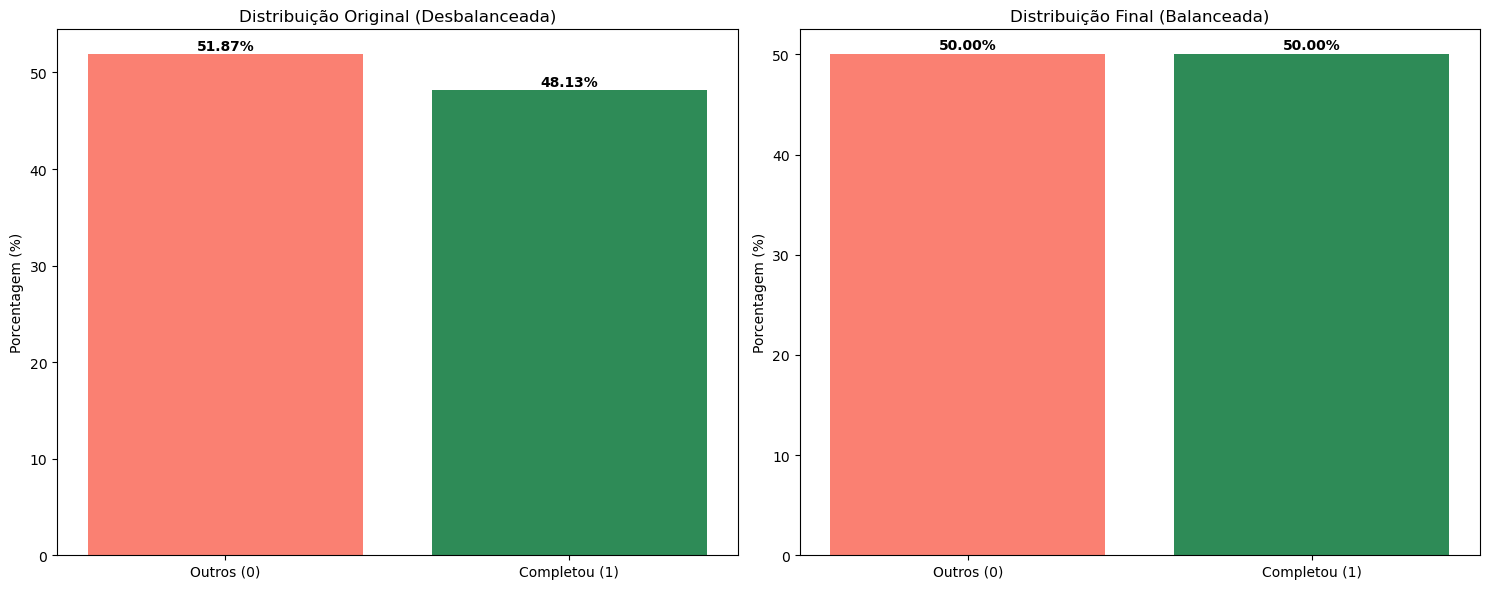

In [25]:
import matplotlib.pyplot as plt

# 1. Coletando os dados consolidados via SQL (Agregação no Spark)
# O .collect() traz apenas as linhas resultantes (neste caso, 2 linhas)
dist_original = spark.sql("""
                          SELECT target, ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM master_table), 2) as pct
                          FROM master_table GROUP BY target ORDER BY target
                          """).collect()

dist_balanced = spark.sql("""
                          SELECT target, ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM balanced_master_table), 2) as pct
                          FROM balanced_master_table GROUP BY target ORDER BY target
                          """).collect()

# Preparando listas para o Matplotlib
labels = ['Outros (0)', 'Completou (1)']
valores_orig = [row['pct'] for row in dist_original]
valores_bal = [row['pct'] for row in dist_balanced]

# Criando a visualização
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Original
ax1.bar(labels, valores_orig, color=['salmon', 'seagreen'])
ax1.set_title('Distribuição Original (Desbalanceada)')
ax1.set_ylabel('Porcentagem (%)')
for i, v in enumerate(valores_orig):
    # Convertendo v para float para permitir a soma
    ax1.text(i, float(v) + 0.5, f"{v}%", ha='center', fontweight='bold')

# Gráfico 2: Balanceado
ax2.bar(labels, valores_bal, color=['salmon', 'seagreen'])
ax2.set_title('Distribuição Final (Balanceada)')
ax2.set_ylabel('Porcentagem (%)')
for i, v in enumerate(valores_bal):
    # Convertendo v para float para permitir a soma
    ax2.text(i, float(v) + 0.5, f"{v}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

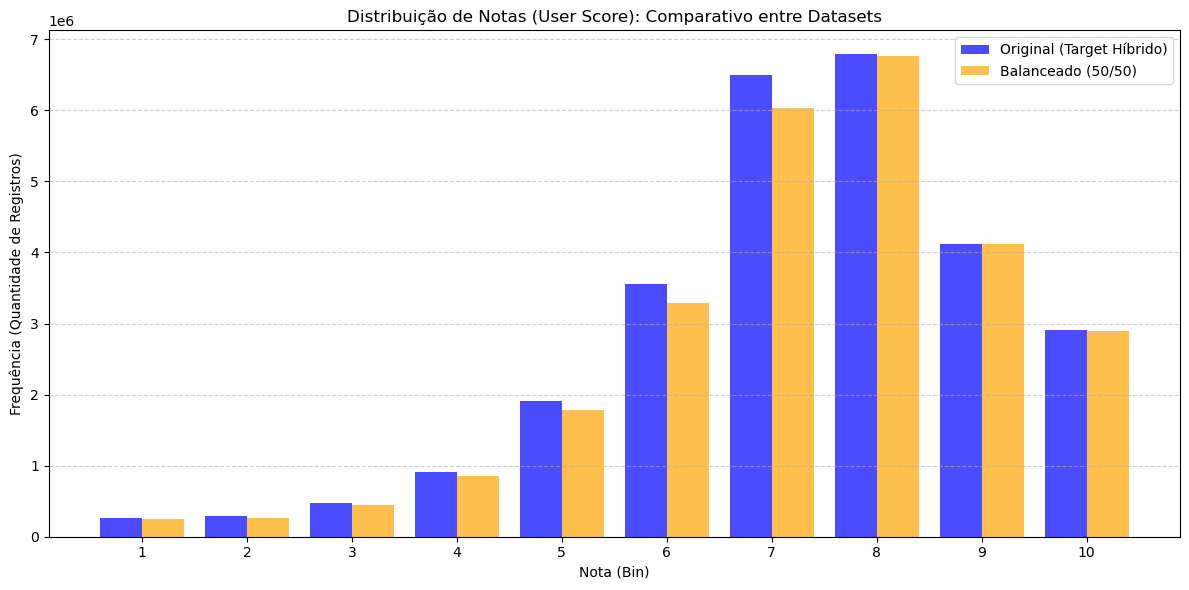

In [26]:
# 1. Agregação do Histograma via SQL para o Dataset Original
# Criamos 10 buckets (faixas) para as notas de 1 a 10
hist_orig_df = spark.sql("""
                         SELECT
                             floor(user_score) as bin,
                             COUNT(*) as count
                         FROM master_table
                         GROUP BY bin
                         ORDER BY bin
                         """).collect()

# 2. Agregação do Histograma via SQL para o Dataset Balanceado
hist_bal_df = spark.sql("""
                        SELECT
                            floor(user_score) as bin,
                            COUNT(*) as count
                        FROM balanced_master_table
                        GROUP BY bin
                        ORDER BY bin
                        """).collect()

# 3. Preparando os dados para o Matplotlib
# Extraímos os valores das linhas retornadas pelo collect
bins_orig = [float(row['bin']) for row in hist_orig_df]
counts_orig = [row['count'] for row in hist_orig_df]

bins_bal = [float(row['bin']) for row in hist_bal_df]
counts_bal = [row['count'] for row in hist_bal_df]

# Criando o gráfico
fig, ax = plt.subplots(figsize=(12, 6))

# Largura das barras
width = 0.4

# Plotando as barras lado a lado para comparação clara
ax.bar([b - width/2 for b in bins_orig], counts_orig, width=width, label='Original (Target Híbrido)', color='blue', alpha=0.7)
ax.bar([b + width/2 for b in bins_bal], counts_bal, width=width, label='Balanceado (50/50)', color='orange', alpha=0.7)

ax.set_title('Distribuição de Notas (User Score): Comparativo entre Datasets')
ax.set_xlabel('Nota (Bin)')
ax.set_ylabel('Frequência (Quantidade de Registros)')
ax.set_xticks(range(1, 11))
ax.legend()

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Análise de Insights: O Impacto da Duração no Enjoyment

A comparação entre os datasets **Original** (27M de linhas) e **Balanced/Undersample** (26M de linhas) revela uma consistência impressionante nas métricas de comportamento do usuário, validando a eficácia da amostragem.

#### 1. A Consistência do Enjoyment (Taxa de Satisfação)
Observa-se que a taxa de **Enjoyment** (Completou + Nota >= 8) é significativamente menor em animes **Curtos (44.6%)** em comparação aos animes **Padrão e Longos (~55%)**.

* **Insight:** Embora animes curtos tenham o maior volume de avaliações (18M no original), eles possuem a menor taxa de satisfação real. Isso sugere que a facilidade de terminar um anime curto não garante que o usuário irá amá-lo.

#### 2. O Ponto Ideal: 13 a 100 Episódios
As faixas "Padrão" e "Longo" apresentam o maior equilíbrio entre retenção e qualidade percebida:
* **Taxa de Enjoyment:** Estabiliza em torno de **55.4%**.
* **Média de Nota:** Sobe para a casa dos **7.6 a 7.7**, superando os animes curtos (7.16).

#### 3. O Paradoxo do Grupo Épico (100+)
Os animes com mais de 100 episódios mantêm uma taxa de Enjoyment robusta (**51.84%**) e notas altas.
* **Fidelização:** Isso indica que, se um usuário ultrapassa a barreira inicial de uma obra monumental, a probabilidade de ele atingir um estado de "Alta Satisfação" é maior do que em obras casuais de 12 episódios.

#### 4. Validação do Undersampling
A comparação entre as imagens demonstra que o processo de Undersampling foi cirúrgico:
* As médias de nota (`media_nota_usuario`) permaneceram idênticas até a segunda casa decimal.
* As taxas de `enjoyment` flutuaram menos de 0.1%.

**Conclusão Estratégica:**
O modelo de Machine Learning não será enviesado pelo volume massivo de animes curtos. Graças ao balanceamento, o algoritmo terá sensibilidade para identificar o "usuário de nicho" que prefere obras densas e longas, onde a satisfação final tende a ser estatisticamente superior.

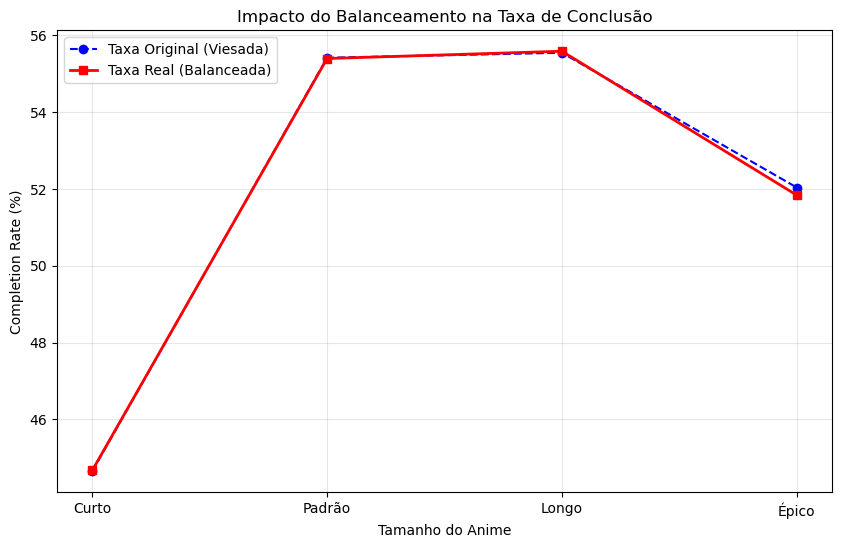

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Comparação da Enjoyment Rate com base em faixas
faixas = ['Curto', 'Padrão', 'Longo', 'Épico']
taxa_orig = [44.65, 55.42, 55.55, 52.04]
taxa_bal = [44.67, 55.4, 55.59, 51.84]

plt.figure(figsize=(10, 6))
plt.plot(faixas, taxa_orig, marker='o', label='Taxa Original (Viesada)', color='blue', linestyle='--')
plt.plot(faixas, taxa_bal, marker='s', label='Taxa Real (Balanceada)', color='red', linewidth=2)

plt.title('Impacto do Balanceamento na Taxa de Conclusão')
plt.xlabel('Tamanho do Anime')
plt.ylabel('Completion Rate (%)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

---

## Fase de Modelagem: Predição de Engajamento Real

Com o dataset devidamente tratado, as anomalias de episódios corrigidas e uma **coluna alvo (target)** definida estrategicamente, iniciamos a fase de treinamento.

### Definição do Experimento
O objetivo é comparar a performance da rede neural **Multilayer Perceptron (MLPC)** em dois cenários distintos, utilizando estritamente o **Spark MLlib**:

1.  **Dataset Master (Original):** Contendo a distribuição natural dos dados (~27M de registros).
2.  **Dataset Undersampled:** Balanceado artificialmente para uma proporção 50/50, visando mitigar o viés de predição.

### O Alvo: High Engagement
Diferente de uma predição de "status" simples, nosso modelo busca prever o **Engajamento de Alta Satisfação**, onde:
*   **Target 1:** Usuário completou o anime **E** atribuiu nota $\ge 8$.
*   **Target 0:** Usuário não completou **OU** completou com nota $< 8$.

Esta abordagem transforma o problema em uma classificação binária robusta, ideal para sistemas de recomendação de alta precisão.

---

---

## Implementação de Rede Neural (Multilayer Perceptron)

A seguir, a implementação de **Neural Network** para a previsão da coluna alvo consiste na aplicação do algoritmo **Multilayer Perceptron Classifier (MLPC)**, utilizando a biblioteca **Spark MLlib**. O objetivo é avaliar a capacidade do modelo em aprender os padrões de "Engajamento Real" em diferentes cenários de distribuição de dados.

### Arquitetura do Modelo
A rede neural foi estruturada em um modelo *feedforward* com as seguintes camadas:
1.  **Camada de Entrada (Input Layer):** 4 neurônios, correspondentes às features processadas (`total_episodes`, `anime_score`, `type` e `source`).
2.  **Camadas Ocultas (Hidden Layers):** Duas camadas intermediárias com **32** e **16** neurônios respectivamente, utilizando funções de ativação para capturar relações não-lineares.
3.  **Camada de Saída (Output Layer):** 2 neurônios com função *Softmax*, representando as probabilidades das classes do target (0 ou 1).

### Objetivos da Análise
O experimento busca comparar o desempenho preditivo entre:
*   **Dataset Master (27M):** Base completa com distribuição original, onde o desafio é lidar com o viés natural dos dados.
*   **Dataset Undersample (26M):** Base equilibrada via técnica de subamostragem, visando otimizar a sensibilidade (*Recall*) do modelo para a classe de alto engajamento.

### Métricas de Avaliação
Para garantir uma análise rigorosa, além da **Acurácia**, utilizaremos **F1-Score**, **Precision** e **Recall**. O foco principal reside no ganho de *Recall* no dataset balanceado, o que indicaria uma melhor identificação de usuários altamente satisfeitos, reduzindo os falsos negativos.

---

In [28]:
df_master_nn = spark.read.parquet(f"{output_path}/master_table")
df_master_undersample = spark.read.parquet(f"{output_path}/master_table_undersample")

In [29]:
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler
from pyspark.ml.classification import MultilayerPerceptronClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml import Pipeline
import time

# --- 1. Configurações Globais ---
categorical_cols = ["anime_type", "anime_source"]
numeric_cols = ["total_episodes", "anime_score"]
layers = [4, 32, 16, 2]

# --- 2. Definição do Pipeline de Machine Learning ---
indexers = [StringIndexer(inputCol=col, outputCol=f"{col}_idx", handleInvalid="keep") for col in categorical_cols]

assembler = VectorAssembler(
    inputCols=[f"{col}_idx" for col in categorical_cols] + numeric_cols,
    outputCol="features_unscaled",
    handleInvalid="skip"
)

scaler = StandardScaler(inputCol="features_unscaled", outputCol="features", withStd=True, withMean=False)

mlp = MultilayerPerceptronClassifier(
    layers=layers,
    blockSize=128,
    seed=42,
    maxIter=100,
    featuresCol="features",
    labelCol="target"
)

pipeline = Pipeline(stages=indexers + [assembler, scaler, mlp])

# --- 3. Função de Treino e Avaliação (SQL Only Edition) ---
def train_and_evaluate(df, name):
    print(f"\n" + "="*60)
    print(f"INICIANDO PROCESSO: {name}")
    print("="*60)

    # Identificador único para as views não colidirem entre execuções
    tag = name.lower().replace(' ', '_')

    # Etapa 1: Limpeza via SQL
    print(f"[1/7] Injetando SQL para limpeza e casting...")
    df.createOrReplaceTempView(f"raw_{tag}")

    query_clean = f"""
        SELECT
            CAST(anime_type AS STRING) as anime_type,
            CAST(anime_source AS STRING) as anime_source,
            CAST(total_episodes AS DOUBLE) as total_episodes,
            CAST(anime_score AS DOUBLE) as anime_score,
            CAST(target AS INT) as target
        FROM raw_{tag}
        WHERE anime_type IS NOT NULL
          AND anime_source IS NOT NULL
          AND total_episodes IS NOT NULL
          AND anime_score IS NOT NULL
          AND target IS NOT NULL
    """
    df_clean = spark.sql(query_clean)
    df_clean.createOrReplaceTempView(f"clean_{tag}")

    # Count via SQL
    count_clean = spark.sql(f"SELECT COUNT(*) FROM clean_{tag}").collect()[0][0]
    print(f"      - SQL Check: {count_clean} registros válidos encontrados.")

    # Etapa 2: Split
    print("[2/7] Realizando split dos dados...")
    train_df, test_df = df_clean.randomSplit([0.8, 0.2], seed=42)

    # Registrando views para o split para contar via SQL
    train_df.createOrReplaceTempView(f"train_{tag}")
    test_df.createOrReplaceTempView(f"test_{tag}")

    count_train = spark.sql(f"SELECT COUNT(*) FROM train_{tag}").collect()[0][0]
    count_test = spark.sql(f"SELECT COUNT(*) FROM test_{tag}").collect()[0][0]

    print(f"      - SQL Split Check: Treino = {count_train} | Teste = {count_test}")

    # Etapa 3: Fit do Pipeline
    print("[3/7] Iniciando o Fit do Pipeline... (Rede Neural em treinamento)")
    start_fit = time.time()
    model = pipeline.fit(train_df)
    print(f"      - Treinamento concluído em {time.time() - start_fit:.2f}s.")

    # Etapa 4: Predições
    print("[4/7] Gerando predições via transform...")
    predictions = model.transform(test_df)

    # Etapa 5: Avaliação Técnica
    print("[5/7] Calculando métricas de performance...")
    evaluator = MulticlassClassificationEvaluator(labelCol="target", predictionCol="prediction")

    accuracy = evaluator.evaluate(predictions, {evaluator.metricName: "accuracy"})
    f1 = evaluator.evaluate(predictions, {evaluator.metricName: "f1"})
    precision = evaluator.evaluate(predictions, {evaluator.metricName: "weightedPrecision"})
    recall = evaluator.evaluate(predictions, {evaluator.metricName: "weightedRecall"})

    # Etapa 6: Display
    print("\n" + "-"*30)
    print(f" RESULTADOS: {name}")
    print(f" - Accuracy:  {accuracy:.4f}")
    print(f" - F1-Score:  {f1:.4f}")
    print(f" - Precision: {precision:.4f}")
    print(f" - Recall:    {recall:.4f}")
    print("-"*30)

    print(f"[7/7] Processo {name} finalizado com sucesso.")
    return model, predictions

# --- 4. Execução dos Fluxos ---

# Execução para o Dataset Original
try:
    model_orig, preds_orig = train_and_evaluate(df_master_nn, "Master Table Original")
except Exception as e:
    print(f"Erro no processo Original: {e}")

# Execução para o Dataset Undersample
try:
    model_bal, preds_bal = train_and_evaluate(df_master_undersample, "Master Table Undersample")
except Exception as e:
    print(f"Erro no processo Balanceado: {e}")


INICIANDO PROCESSO: Master Table Original
[1/7] Injetando SQL para limpeza e casting...
      - SQL Check: 27575427 registros válidos encontrados.
[2/7] Realizando split dos dados...
      - SQL Split Check: Treino = 22059976 | Teste = 5515451
[3/7] Iniciando o Fit do Pipeline... (Rede Neural em treinamento)
      - Treinamento concluído em 874.42s.
[4/7] Gerando predições via transform...
[5/7] Calculando métricas de performance...

------------------------------
 RESULTADOS: Master Table Original
 - Accuracy:  0.6826
 - F1-Score:  0.6820
 - Precision: 0.6825
 - Recall:    0.6826
------------------------------
[7/7] Processo Master Table Original finalizado com sucesso.

INICIANDO PROCESSO: Master Table Undersample
[1/7] Injetando SQL para limpeza e casting...
      - SQL Check: 26547113 registros válidos encontrados.
[2/7] Realizando split dos dados...
      - SQL Split Check: Treino = 21236929 | Teste = 5310184
[3/7] Iniciando o Fit do Pipeline... (Rede Neural em treinamento)
     